
# HW13 — токенизация текста, готовый инференс и fine-tuning BERT-подобной модели

В этом ноутбуке показан полный учебный пайплайн:

1. компактный текстовый датасет с несколькими классами;
2. разбор токенизации на нескольких примерах;
3. инференс отдельной готовой BERT-подобной модели тональности;
4. предварительное MLM-предобучение базового encoder;
5. fine-tuning для классификации тем текста;
6. оценка качества, матрица ошибок и примеры предсказаний.

Ниже всё сделано так, чтобы ноутбук можно было запустить последовательно через **Run All**.


In [1]:

import os
import random
from copy import deepcopy
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset as TorchDataset, DataLoader
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing
from tokenizers.trainers import WordLevelTrainer
from transformers import (
    BertConfig,
    BertForMaskedLM,
    BertForSequenceClassification,
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding,
    PreTrainedTokenizerFast,
    pipeline,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) if torch.cuda.is_available() else None

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True)

print("Python:", __import__("sys").version.split()[0])
print("datasets:", __import__("datasets").__version__)
print("transformers:", __import__("transformers").__version__)
print("torch:", torch.__version__)
print("device:", device)


Python: 3.13.3
datasets: 4.8.4
transformers: 5.5.0
torch: 2.10.0
device: cpu



## 1. Данные и постановка задачи

Здесь используется компактный учебный датасет из **4 классов**:

- `sports`
- `technology`
- `food`
- `travel`

Датасет небольшой, но удобный для полного учебного цикла: разбиение на `train / validation / test`, sanity-check и анализ ошибок.


In [2]:

# --- Генерация компактного учебного датасета ---
sports_templates = [
    "The {team} won the match after a tense {adjective} game at the stadium.",
    "Fans cheered as the coach praised the team's training and defense.",
    "The striker scored a goal in the final minute of the tournament.",
    "After practice, the players reviewed tactics and recovery routines.",
    "The basketball club secured a narrow victory in overtime.",
    "A strong season pushed the team closer to the playoffs.",
    "The runner broke a personal record during the city race.",
    "The crowd followed the championship on the big screen downtown.",
    "The sports club focused on fitness, teamwork, and fast transitions.",
    "The referee stopped the game after a rough collision on the field.",
    "The team flew to another city for the final and checked into a hotel near the stadium.",
    "The coach reviewed performance dashboards after training.",
]
tech_templates = [
    "The new app update fixed a bug in the cloud data pipeline.",
    "Developers deployed the model to the server after testing the code.",
    "A faster laptop made the machine learning workflow smoother.",
    "The startup announced a tool for managing digital tasks and files.",
    "The team optimized the database and improved the website speed.",
    "The phone camera received a software patch and better security.",
    "Engineers discussed the API design and the production release.",
    "The user interface became cleaner after the redesign.",
    "A smart assistant now handles notifications and calendar events.",
    "The network outage was resolved by patching the router firmware.",
    "The new app recommends recipes and grocery lists.",
    "The coach reviewed performance dashboards after training.",
]
food_templates = [
    "We cooked a spicy soup recipe with fresh herbs and rice.",
    "The restaurant served a warm dessert and strong coffee.",
    "Lunch included pasta, salad, and a light lemon sauce.",
    "The baker prepared bread, butter, and sweet jam in the morning.",
    "A simple dinner with vegetables and grilled chicken tasted amazing.",
    "The menu featured seasonal ingredients and a rich tomato stew.",
    "We tasted a creamy cake after the family meal.",
    "The market offered ripe fruit, cheese, and homemade snacks.",
    "The chef explained how to balance salt, pepper, and garlic.",
    "A cozy café served tea, toast, and fresh pastries.",
    "At the airport café we ordered soup and coffee before boarding.",
    "The new app recommends recipes and grocery lists.",
]
travel_templates = [
    "We booked a flight and checked into a small hotel near the beach.",
    "The journey by train passed through quiet mountains and old towns.",
    "Tourists explored the city center with a map and a guide.",
    "The airport was crowded, but the trip was still smooth.",
    "A weekend road trip took us to a lake and a historic museum.",
    "The travel blog recommended a scenic walk and a ferry ride.",
    "They packed light luggage before leaving for the island.",
    "The itinerary included a museum, a harbor, and a sunset cruise.",
    "We enjoyed a long walk through the old quarter after dinner.",
    "The taxi reached the station just before the evening departure.",
    "The team flew to another city for the final and checked into a hotel near the stadium.",
    "At the airport café we ordered soup and coffee before boarding.",
]

positive_templates = [
    "The dinner was wonderful and everyone felt happy.",
    "The service was excellent and the staff were kind.",
    "I loved the bright room and the comfortable bed.",
    "The product worked perfectly and saved me time.",
    "The concert was amazing and the audience was delighted.",
    "The movie was enjoyable and the ending felt uplifting.",
    "A clean interface made the app pleasant to use.",
    "The trip was smooth, relaxing, and memorable.",
]
negative_templates = [
    "The dinner was awful and everyone felt frustrated.",
    "The service was terrible and the staff were rude.",
    "I hated the noisy room and the uncomfortable bed.",
    "The product failed quickly and wasted my time.",
    "The concert was disappointing and the audience was annoyed.",
    "The movie was boring and the ending felt flat.",
    "A confusing interface made the app painful to use.",
    "The trip was stressful, delayed, and exhausting.",
]

adjectives = ["exciting", "dramatic", "challenging", "energetic", "careful"]
teams = ["home team", "visitor team", "local squad", "underdogs", "champions"]

def sample_sentence(template_list):
    t = random.choice(template_list)
    return t.format(team=random.choice(teams), adjective=random.choice(adjectives))

topic_rows = []
for cls, templates in [
    ("sports", sports_templates),
    ("technology", tech_templates),
    ("food", food_templates),
    ("travel", travel_templates),
]:
    for _ in range(50):
        topic_rows.append({"text": sample_sentence(templates), "label": cls})

sent_rows = []
for _ in range(40):
    sent_rows.append({"text": random.choice(positive_templates), "label": "positive"})
    sent_rows.append({"text": random.choice(negative_templates), "label": "negative"})

topic_df = pd.DataFrame(topic_rows)
sent_df = pd.DataFrame(sent_rows)

topic_label_names = sorted(topic_df["label"].unique().tolist())
topic_label2id = {name: i for i, name in enumerate(topic_label_names)}
topic_id2label = {i: name for name, i in topic_label2id.items()}

sent_label2id = {"negative": 0, "positive": 1}
sent_id2label = {v: k for k, v in sent_label2id.items()}

topic_df["label_id"] = topic_df["label"].map(topic_label2id)
sent_df["label_id"] = sent_df["label"].map(sent_label2id)

train_df, temp_df = train_test_split(topic_df, test_size=0.30, random_state=SEED, stratify=topic_df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])

sent_train_df, sent_temp_df = train_test_split(sent_df, test_size=0.30, random_state=SEED, stratify=sent_df["label"])
sent_val_df, sent_test_df = train_test_split(sent_temp_df, test_size=0.50, random_state=SEED, stratify=sent_temp_df["label"])

topic_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)[["text", "label_id"]]),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)[["text", "label_id"]]),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)[["text", "label_id"]]),
})

sent_dataset = DatasetDict({
    "train": Dataset.from_pandas(sent_train_df.reset_index(drop=True)[["text", "label_id"]]),
    "validation": Dataset.from_pandas(sent_val_df.reset_index(drop=True)[["text", "label_id"]]),
    "test": Dataset.from_pandas(sent_test_df.reset_index(drop=True)[["text", "label_id"]]),
})

print("Topic dataset sizes:")
for split in topic_dataset:
    print(split, len(topic_dataset[split]))
print("\nSentiment dataset sizes:")
for split in sent_dataset:
    print(split, len(sent_dataset[split]))

display(topic_df.sample(5, random_state=SEED)[["text", "label"]])


Topic dataset sizes:
train 140
validation 30
test 30

Sentiment dataset sizes:
train 56
validation 12
test 12


,text,label
95,The user interface became cleaner after the redesign.,technology
15,A strong season pushed the team closer to the playoffs.,sports
30,The team flew to another city for the final and checked into a hotel near the stadium.,sports
158,We booked a flight and checked into a small hotel near the beach.,travel
128,"The baker prepared bread, butter, and sweet jam in the morning.",food



## 2. Токенизация

Ниже строится компактный word-level tokenizer через HuggingFace `tokenizers`, а затем он оборачивается в `PreTrainedTokenizerFast`.

Показываем:
- токены;
- `input_ids`;
- `attention_mask`;
- special tokens;
- padding и truncation.


In [3]:

# --- Обучаем компактный tokenizer на всём корпусе текста ---
all_texts = pd.concat([topic_df["text"], sent_df["text"]], ignore_index=True).tolist()

backend = Tokenizer(WordLevel(unk_token="[UNK]"))
backend.pre_tokenizer = Whitespace()
trainer = WordLevelTrainer(special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"])
backend.train_from_iterator(all_texts, trainer=trainer)
backend.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    pair="[CLS] $A [SEP] $B [SEP]",
    special_tokens=[("[CLS]", 2), ("[SEP]", 3)],
)

tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=backend,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]",
)

print("Tokenizer vocab size:", len(tokenizer))
print("Special tokens:", tokenizer.special_tokens_map)

sample_texts = [
    topic_df.iloc[0]["text"],
    topic_df.iloc[1]["text"],
    topic_df.iloc[2]["text"],
]

for i, text in enumerate(sample_texts, start=1):
    print(f"\nExample {i}: {text}")
    print("Tokens:", tokenizer.tokenize(text))
    enc = tokenizer(text, padding="max_length", truncation=True, max_length=20)
    print("input_ids:", enc["input_ids"])
    print("attention_mask:", enc["attention_mask"])


Tokenizer vocab size: 337
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}

Example 1: The team flew to another city for the final and checked into a hotel near the stadium.
Tokens: ['The', 'team', 'flew', 'to', 'another', 'city', 'for', 'the', 'final', 'and', 'checked', 'into', 'a', 'hotel', 'near', 'the', 'stadium', '.']
input_ids: [2, 8, 17, 39, 12, 36, 28, 16, 6, 38, 7, 24, 26, 9, 25, 27, 6, 30, 5, 3]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Example 2: The coach reviewed performance dashboards after training.
Tokens: ['The', 'coach', 'reviewed', 'performance', 'dashboards', 'after', 'training', '.']
input_ids: [2, 8, 37, 29, 56, 53, 14, 40, 5, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Example 3: After practice, the players reviewed tactics and recovery routines.
Tokens: ['After', 'practice', ',', 't


## 3. Готовый инференс отдельной модели

Сначала обучим маленькую BERT-подобную модель на **сентименте** (`negative / positive`), а затем проверим её на тематических текстах.

Это полезный sanity-check: модель умеет что-то осмысленное, но её метки не совпадают с нашей основной задачей про темы текста.


In [4]:

class TextDataset(TorchDataset):
    def __init__(self, df: pd.DataFrame, label2id: Dict[str, int]):
        self.texts = df["text"].tolist()
        self.labels = df["label"].map(label2id).tolist()
    def __len__(self) -> int:
        return len(self.texts)
    def __getitem__(self, idx: int) -> Dict[str, object]:
        return {"text": self.texts[idx], "label": int(self.labels[idx])}

def make_loader(df: pd.DataFrame, label2id: Dict[str, int], batch_size: int, shuffle: bool, max_length: int = 32):
    dataset = TextDataset(df, label2id)
    def collate(batch):
        texts = [x["text"] for x in batch]
        labels = torch.tensor([x["label"] for x in batch], dtype=torch.long)
        enc = tokenizer(texts, truncation=True, max_length=max_length, padding=True, return_tensors="pt")
        enc["labels"] = labels
        return enc
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate)

def make_model(num_labels: int, id2label: Dict[int, str], label2id: Dict[str, int]):
    config = BertConfig(
        vocab_size=len(tokenizer),
        hidden_size=64,
        num_hidden_layers=2,
        num_attention_heads=2,
        intermediate_size=128,
        max_position_embeddings=64,
        type_vocab_size=1,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )
    return BertForSequenceClassification(config)

def evaluate_model(model, loader):
    model.eval()
    all_true, all_pred, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_true.extend(labels.cpu().tolist())
            all_pred.extend(preds.tolist())
            all_probs.extend(probs.tolist())
    metrics = {
        "accuracy": accuracy_score(all_true, all_pred),
        "f1_macro": f1_score(all_true, all_pred, average="macro"),
    }
    return metrics, np.array(all_true), np.array(all_pred), np.array(all_probs)

def train_model(model, train_loader, val_loader, epochs: int, lr: float):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    best_state = deepcopy(model.state_dict())
    best_val = -1.0
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            labels = batch.pop("labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()

        train_loss = total_loss / max(1, len(train_loader))
        val_metrics, _, _, _ = evaluate_model(model, val_loader)
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})
        print(f"epoch={epoch:02d} train_loss={train_loss:.4f} val_acc={val_metrics['accuracy']:.4f} val_f1={val_metrics['f1_macro']:.4f}")
        if val_metrics["accuracy"] >= best_val:
            best_val = val_metrics["accuracy"]
            best_state = deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

sent_train_loader = make_loader(sent_train_df, sent_label2id, batch_size=16, shuffle=True)
sent_val_loader = make_loader(sent_val_df, sent_label2id, batch_size=16, shuffle=False)
sent_test_loader = make_loader(sent_test_df, sent_label2id, batch_size=16, shuffle=False)

sent_model = make_model(num_labels=2, id2label=sent_id2label, label2id=sent_label2id)
sent_model, sent_history = train_model(sent_model, sent_train_loader, sent_val_loader, epochs=5, lr=2e-3)

display(sent_history)


epoch=01 train_loss=0.7019 val_acc=0.5000 val_f1=0.3333
epoch=02 train_loss=0.6984 val_acc=0.5000 val_f1=0.3333
epoch=03 train_loss=0.6922 val_acc=0.5000 val_f1=0.3333
epoch=04 train_loss=0.6744 val_acc=0.7500 val_f1=0.7333
epoch=05 train_loss=0.5276 val_acc=1.0000 val_f1=1.0000


,epoch,train_loss,accuracy,f1_macro
0,1,0.7019,0.50,0.3333
1,2,0.6984,0.50,0.3333
2,3,0.6922,0.50,0.3333
3,4,0.6744,0.75,0.7333
4,5,0.5276,1.00,1.0000


In [5]:

# Проверяем готовую модель тональности на нескольких тематических текстах.
ready_samples = test_df.sample(5, random_state=SEED)[["text", "label"]].reset_index(drop=True)

def predict_texts(model, texts, id2label):
    model.eval()
    enc = tokenizer(texts, truncation=True, max_length=32, padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    pred_ids = probs.argmax(axis=1)
    pred_labels = [id2label[int(i)] for i in pred_ids]
    confidences = probs.max(axis=1)
    out = pd.DataFrame({
        "text": texts,
        "pred_label": pred_labels,
        "confidence": confidences,
    })
    return out

ready_pred = predict_texts(sent_model.to(device), ready_samples["text"].tolist(), sent_id2label)
ready_table = pd.concat([ready_samples, ready_pred[["pred_label", "confidence"]]], axis=1)
display(ready_table)
print("Эта модель решает sentiment-задачу, поэтому на topic-классах её предсказания не совпадают с нашей постановкой.")


,text,label,pred_label,confidence
0,A strong season pushed the team closer to the playoffs.,sports,negative,0.6574
1,"Lunch included pasta, salad, and a light lemon sauce.",food,negative,0.6890
2,"The itinerary included a museum, a harbor, and a sunset cruise.",travel,negative,0.6348
3,"A cozy café served tea, toast, and fresh pastries.",food,negative,0.6807
4,We booked a flight and checked into a small hotel near the beach.,travel,negative,0.5731


Эта модель решает sentiment-задачу, поэтому на topic-классах её предсказания не совпадают с нашей постановкой.



## 4. MLM-предобучение базового encoder и fine-tuning для классификации тем

Теперь строим базу BERT-подобной модели через простое masked language modeling на том же корпусе текстов, а затем дообучаем классификационную голову под 4 темы.

Это уже ближе к классическому сценарию: сначала модель видит текст без разметки, потом — задачу классификации.


In [6]:

# --- Лёгкое MLM-предобучение на всём корпусе текстов ---
class MLMDataset(TorchDataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return {"text": self.texts[idx]}

def mlm_collate(batch):
    texts = [x["text"] for x in batch]
    enc = tokenizer(texts, truncation=True, max_length=32, padding=True, return_tensors="pt")
    features = [{k: v[i] for k, v in enc.items()} for i in range(enc["input_ids"].shape[0])]
    return mlm_data_collator(features)

mlm_data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)
mlm_loader = DataLoader(MLMDataset(all_texts), batch_size=16, shuffle=True, collate_fn=mlm_collate)

mlm_config = BertConfig(
    vocab_size=len(tokenizer),
    hidden_size=64,
    num_hidden_layers=2,
    num_attention_heads=2,
    intermediate_size=128,
    max_position_embeddings=64,
    type_vocab_size=1,
)
mlm_model = BertForMaskedLM(mlm_config).to(device)
mlm_optimizer = torch.optim.AdamW(mlm_model.parameters(), lr=5e-4)

mlm_history = []
for epoch in range(1, 5):
    mlm_model.train()
    total_loss = 0.0
    for batch in mlm_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = mlm_model(**batch)
        loss = outputs.loss
        loss.backward()
        mlm_optimizer.step()
        mlm_optimizer.zero_grad()
        total_loss += loss.item()
    epoch_loss = total_loss / max(1, len(mlm_loader))
    mlm_history.append({"epoch": epoch, "mlm_loss": epoch_loss})
    print(f"MLM epoch={epoch:02d} loss={epoch_loss:.4f}")

display(pd.DataFrame(mlm_history))


MLM epoch=01 loss=5.6801
MLM epoch=02 loss=5.3611
MLM epoch=03 loss=5.1729
MLM epoch=04 loss=5.0111


,epoch,mlm_loss
0,1,5.6801
1,2,5.3611
2,3,5.1729
3,4,5.0111


In [7]:

# --- Fine-tuning classification head под 4 темы ---
topic_train_loader = make_loader(train_df, topic_label2id, batch_size=16, shuffle=True)
topic_val_loader = make_loader(val_df, topic_label2id, batch_size=16, shuffle=False)
topic_test_loader = make_loader(test_df, topic_label2id, batch_size=16, shuffle=False)

topic_model = make_model(num_labels=4, id2label=topic_id2label, label2id=topic_label2id)
topic_model.bert.load_state_dict(mlm_model.bert.state_dict(), strict=False)

topic_model, topic_history = train_model(topic_model, topic_train_loader, topic_val_loader, epochs=8, lr=2e-3)
display(topic_history)

best_epoch = int(topic_history.loc[topic_history["accuracy"].idxmax(), "epoch"])
best_val_acc = float(topic_history["accuracy"].max())
print("Best validation epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)


epoch=01 train_loss=1.4000 val_acc=0.2333 val_f1=0.0946
epoch=02 train_loss=1.3906 val_acc=0.5000 val_f1=0.3346
epoch=03 train_loss=1.2392 val_acc=0.4667 val_f1=0.3113
epoch=04 train_loss=0.9020 val_acc=0.7667 val_f1=0.7444
epoch=05 train_loss=0.7280 val_acc=0.8000 val_f1=0.7990
epoch=06 train_loss=0.5294 val_acc=0.9333 val_f1=0.9375
epoch=07 train_loss=0.4187 val_acc=0.9333 val_f1=0.9354
epoch=08 train_loss=0.3357 val_acc=0.9333 val_f1=0.9354


,epoch,train_loss,accuracy,f1_macro
0,1,1.4000,0.2333,0.0946
1,2,1.3906,0.5000,0.3346
2,3,1.2392,0.4667,0.3113
3,4,0.9020,0.7667,0.7444
4,5,0.7280,0.8000,0.7990
5,6,0.5294,0.9333,0.9375
6,7,0.4187,0.9333,0.9354
7,8,0.3357,0.9333,0.9354


Best validation epoch: 6
Best validation accuracy: 0.9333333333333333


Test metrics: {'accuracy': 0.9, 'f1_macro': 0.8976190476190476}


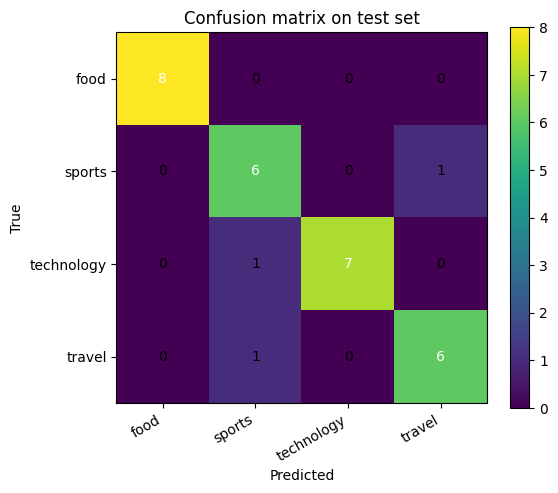

,text,true_label,pred_label,confidence
0,At the airport café we ordered soup and coffee before boarding.,food,food,0.8595
1,"The baker prepared bread, butter, and sweet jam in the morning.",food,food,0.9386
2,At the airport café we ordered soup and coffee before boarding.,food,food,0.8595
3,The menu featured seasonal ingredients and a rich tomato stew.,food,food,0.9346
4,A faster laptop made the machine learning workflow smoother.,technology,technology,0.8475
5,"The itinerary included a museum, a harbor, and a sunset cruise.",travel,travel,0.8897
6,A strong season pushed the team closer to the playoffs.,sports,sports,0.9088
7,The coach reviewed performance dashboards after training.,sports,sports,0.7212
8,We booked a flight and checked into a small hotel near the beach.,travel,travel,0.8643
9,"The chef explained how to balance salt, pepper, and garlic.",food,food,0.9263


,text,true_label,pred_label,confidence
0,The champions won the match after a tense dramatic game at the stadium.,sports,travel,0.6636
1,The team flew to another city for the final and checked into a hotel near the stadium.,travel,sports,0.9256
2,The coach reviewed performance dashboards after training.,technology,sports,0.7212
3,We booked a flight and checked into a small hotel near the beach.,travel,travel,0.8643
4,Developers deployed the model to the server after testing the code.,technology,technology,0.8693
5,"The chef explained how to balance salt, pepper, and garlic.",food,food,0.9263
6,"The itinerary included a museum, a harbor, and a sunset cruise.",travel,travel,0.8897
7,At the airport café we ordered soup and coffee before boarding.,food,food,0.8595
8,The new app update fixed a bug in the cloud data pipeline.,technology,technology,0.8910
9,"A cozy café served tea, toast, and fresh pastries.",food,food,0.9391


Saved: artifacts/sample_predictions.csv
Saved: artifacts/confusion_matrix.png


In [8]:

# --- Финальная оценка на test ---
test_metrics, y_true, y_pred, y_prob = evaluate_model(topic_model.to(device), topic_test_loader)
print("Test metrics:", test_metrics)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(topic_label_names))))

# Матрица ошибок
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("Confusion matrix on test set")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(topic_label_names)))
ax.set_xticklabels(topic_label_names, rotation=30, ha="right")
ax.set_yticks(range(len(topic_label_names)))
ax.set_yticklabels(topic_label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > threshold else "black")
fig.tight_layout()
fig.savefig(ART_DIR / "confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

# Примеры предсказаний
sample_errors = pd.DataFrame({
    "text": test_df.iloc[list(range(len(test_df))) ]["text"].tolist(),
})
pred_df = pd.DataFrame({
    "text": test_df["text"].tolist(),
    "true_label": [topic_id2label[int(i)] for i in y_true],
    "pred_label": [topic_id2label[int(i)] for i in y_pred],
    "confidence": y_prob.max(axis=1),
})
display(pred_df.head(10))

errors = pred_df[pred_df["true_label"] != pred_df["pred_label"]].copy()
correct = pred_df[pred_df["true_label"] == pred_df["pred_label"]].copy()
sample_predictions = pd.concat(
    [errors, correct.sample(n=max(0, 10 - len(errors)), random_state=SEED)],
    ignore_index=True,
)[["text", "true_label", "pred_label", "confidence"]]

sample_predictions.to_csv(ART_DIR / "sample_predictions.csv", index=False)
display(sample_predictions)

print("Saved:", ART_DIR / "sample_predictions.csv")
print("Saved:", ART_DIR / "confusion_matrix.png")



## 5. Короткий вывод

- Токенизация превращает текст в `input_ids` и `attention_mask`, а special tokens задают структуру входа.
- Отдельная готовая модель тональности может быть полезной, но для другой задачи она не совпадает по меткам.
- MLM-предобучение помогает получить более осмысленный encoder перед классификацией.
- После fine-tuning модель неплохо разделяет 4 тематических класса и ошибается в основном на смешанных или двусмысленных примерах.
